In [1]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import collections
import itertools
import seaborn as sns
import tweepy
import datetime
import nltk
from nltk.corpus import stopwords
from PIL import Image
import datetime
from afinn import Afinn
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer 
from sklearn.feature_extraction.text import TfidfVectorizer
import operator
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from networkx.drawing.nx_agraph import graphviz_layout
import nltk

In [2]:
df = pd.read_excel('C:/Users/jwan0/Youtubecrawl_AU_1108.xlsx')

df.head()

,id,content of comments,Translation
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it..."
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism..."
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins."


In [3]:
df = df.astype('string')
df.dtypes

id                     string[python]
content of comments    string[python]
Translation            string[python]
dtype: object

In [4]:
df['Translation'] = df['Translation'].astype(str).str.lower()
df.head()

,id,content of comments,Translation
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it..."
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism..."
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins."


In [5]:
from nltk.tokenize import RegexpTokenizer

regexp = RegexpTokenizer('\w+')

df['text_token']=df['Translation'].apply(regexp.tokenize)
df.head()

,id,content of comments,Translation,text_token
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[as, a, british, living, in, australia, i, can..."
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[well, i, m, british, and, love, australians, ..."
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, you, gotta, roll, with, it, you, gott..."
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[this, is, pretty, well, done, but, the, real,..."
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, done, i, adore, my, australian, ..."


In [6]:
stopwords = nltk.corpus.stopwords.words("english")

# Extend the list with your own custom stopwords
my_stopwords = ['https', 'and', 'this','from','you','that','for','was','are','can','but','all','who','what','where','your','really',
                'made', 'well', 'anyone','guys','name','much', 'put','ever','could', 'one', 'done','come','www','may', 'hey', 'chan',
                'someday', 'still','yet','somehow','first', 'yoooo', '2021', '2020', 'truly', '2019','also', 'degree', 'units', 'skip', 
                'hello', 'soon', 'even', 'really', 'going','greeting', 'come', 'next','looks', 'ahhhh', 'desu', 'get', 'got', 'guy', 
                'make', 'qua','watashi', 'okay', 'yuri', 'com', 'back', 'wait', 'thought','past', 'would', 'lot', 'let', 'though','take',
                "br", 'ji', '18', 'kuvaev', 'sergey' , 'sam', 'yes', 'bloody', 'hell', 'enough', 'billy', 'joel', 'wtf', 'someone',
                'man', 'yeah', 'else', 'mat', 'right', 'another', 'actually', 'upside', 'nah', 'suck', 'always', 'heck', 'ffs', 'onefour',
               'chinese', 'india', 'haha','meanwhile', 'although', 'part', 'already', 'au', 'shit', 'please', 'tara', 'random',
                'something', 'nothing', 'lara', 'year','add', 'thing', 'racist', 'dont', 'unless', 'china', 'meme', 'second',
                'ozi', 'happen', 'bring', 'hugh', 'meh', 'rip', 'dog', 'couple', 'illegal', 'fuck', 'cunt', 'number', 'boy',
                'kmart', 'end', 'guess', 'nobody', 'completely', 'double', 'naked', 'gang', 'many', 'racism', 'spider', 'war',
                'drop', 'eye', 'age', 'die', 'simply', 'eshays', 'quite', 'way', 'without', 'whole', 'pretty']

stopwords.extend(my_stopwords)

In [7]:
df['text_token'] = df['text_token'].apply(lambda x: [item for item in x if item not in stopwords])
df.head()

,id,content of comments,Translation,text_token
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we..."
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini..."
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s..."
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]"
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]"


In [8]:
df['text_string'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if len(item)>2]))

df.head()

,id,content of comments,Translation,text_token,text_string
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins


In [9]:
df[['Translation', 'text_token', 'text_string']].head()

,Translation,text_token,text_string
0,"as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...
1,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...
2,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...
3,"this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire
4,"beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins


In [10]:
#nltk.download('punkt')

#Create a list of all words
all_words = ' '.join([word for word in df['text_string']])

#Tokenize all_words
tokenized_words = nltk.tokenize.word_tokenize(all_words)

#Create a frequency distribution which records the number of times each word has occurred:

from nltk.probability import FreqDist

fdist = FreqDist(tokenized_words)
fdist

FreqDist({'australia': 346, 'australian': 152, 'kylie': 115, 'love': 110, 'like': 101, 'country': 94, 'fire': 66, 'people': 56, 'video': 54, 'see': 53, ...})

In [11]:
df['text_string_fdist'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if fdist[item] >= 1 ]))

In [12]:
df[['Translation','text_token', 'text_string', 'text_string_fdist']].head()

,Translation,text_token,text_string,text_string_fdist
0,"as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...,british living australia say friendly welcome ...
1,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...,british love australians australia definitely ...
2,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...,lyrics roll timeyou say say anybody cause stan...
3,"this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire
4,"beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins,beautifully adore australian cousins


In [13]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word,pos='v') for word in words]
    words = [lemmatizer.lemmatize(word,pos='n') for word in words]
    return ' '.join(words)
df['text_string_lem'] = df['text_string_fdist'].apply(lemmatize_words)

In [14]:
df['is_equal']= (df['text_string_fdist']==df['text_string_lem'])

In [15]:
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...,british living australia say friendly welcome ...,british live australia say friendly welcome op...,False
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...,british love australians australia definitely ...,british love australian australia definitely b...,False
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...,lyrics roll timeyou say say anybody cause stan...,lyric roll timeyou say say anybody cause stand...,False
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,True
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins,beautifully adore australian cousins,beautifully adore australian cousin,False


In [16]:
df = df.dropna()
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...,british living australia say friendly welcome ...,british live australia say friendly welcome op...,False
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...,british love australians australia definitely ...,british love australian australia definitely b...,False
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...,lyrics roll timeyou say say anybody cause stan...,lyric roll timeyou say say anybody cause stand...,False
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,True
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins,beautifully adore australian cousins,beautifully adore australian cousin,False


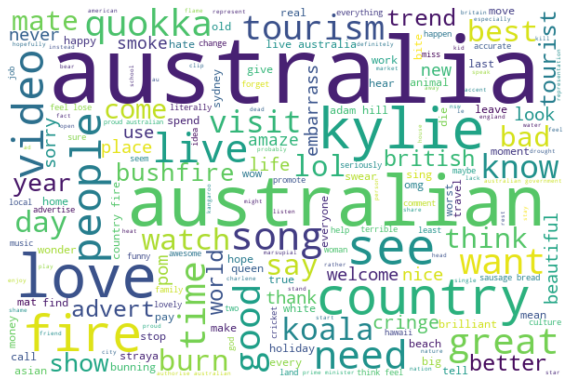

In [17]:
from wordcloud import WordCloud

all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(width=600, 
                     height=400, 
                     random_state=2, 
                     background_color='white', 
                     max_font_size=100).generate(all_words_lem)


plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

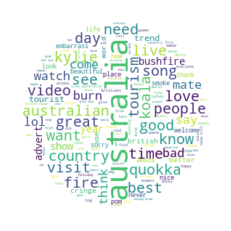

In [18]:
x, y = np.ogrid[:300, :300]
mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
mask = 255 * mask.astype(int)

wc = WordCloud(background_color="white", repeat=True, mask=mask)
wc.generate(all_words_lem)

plt.axis("off")
plt.imshow(wc, interpolation="bilinear");

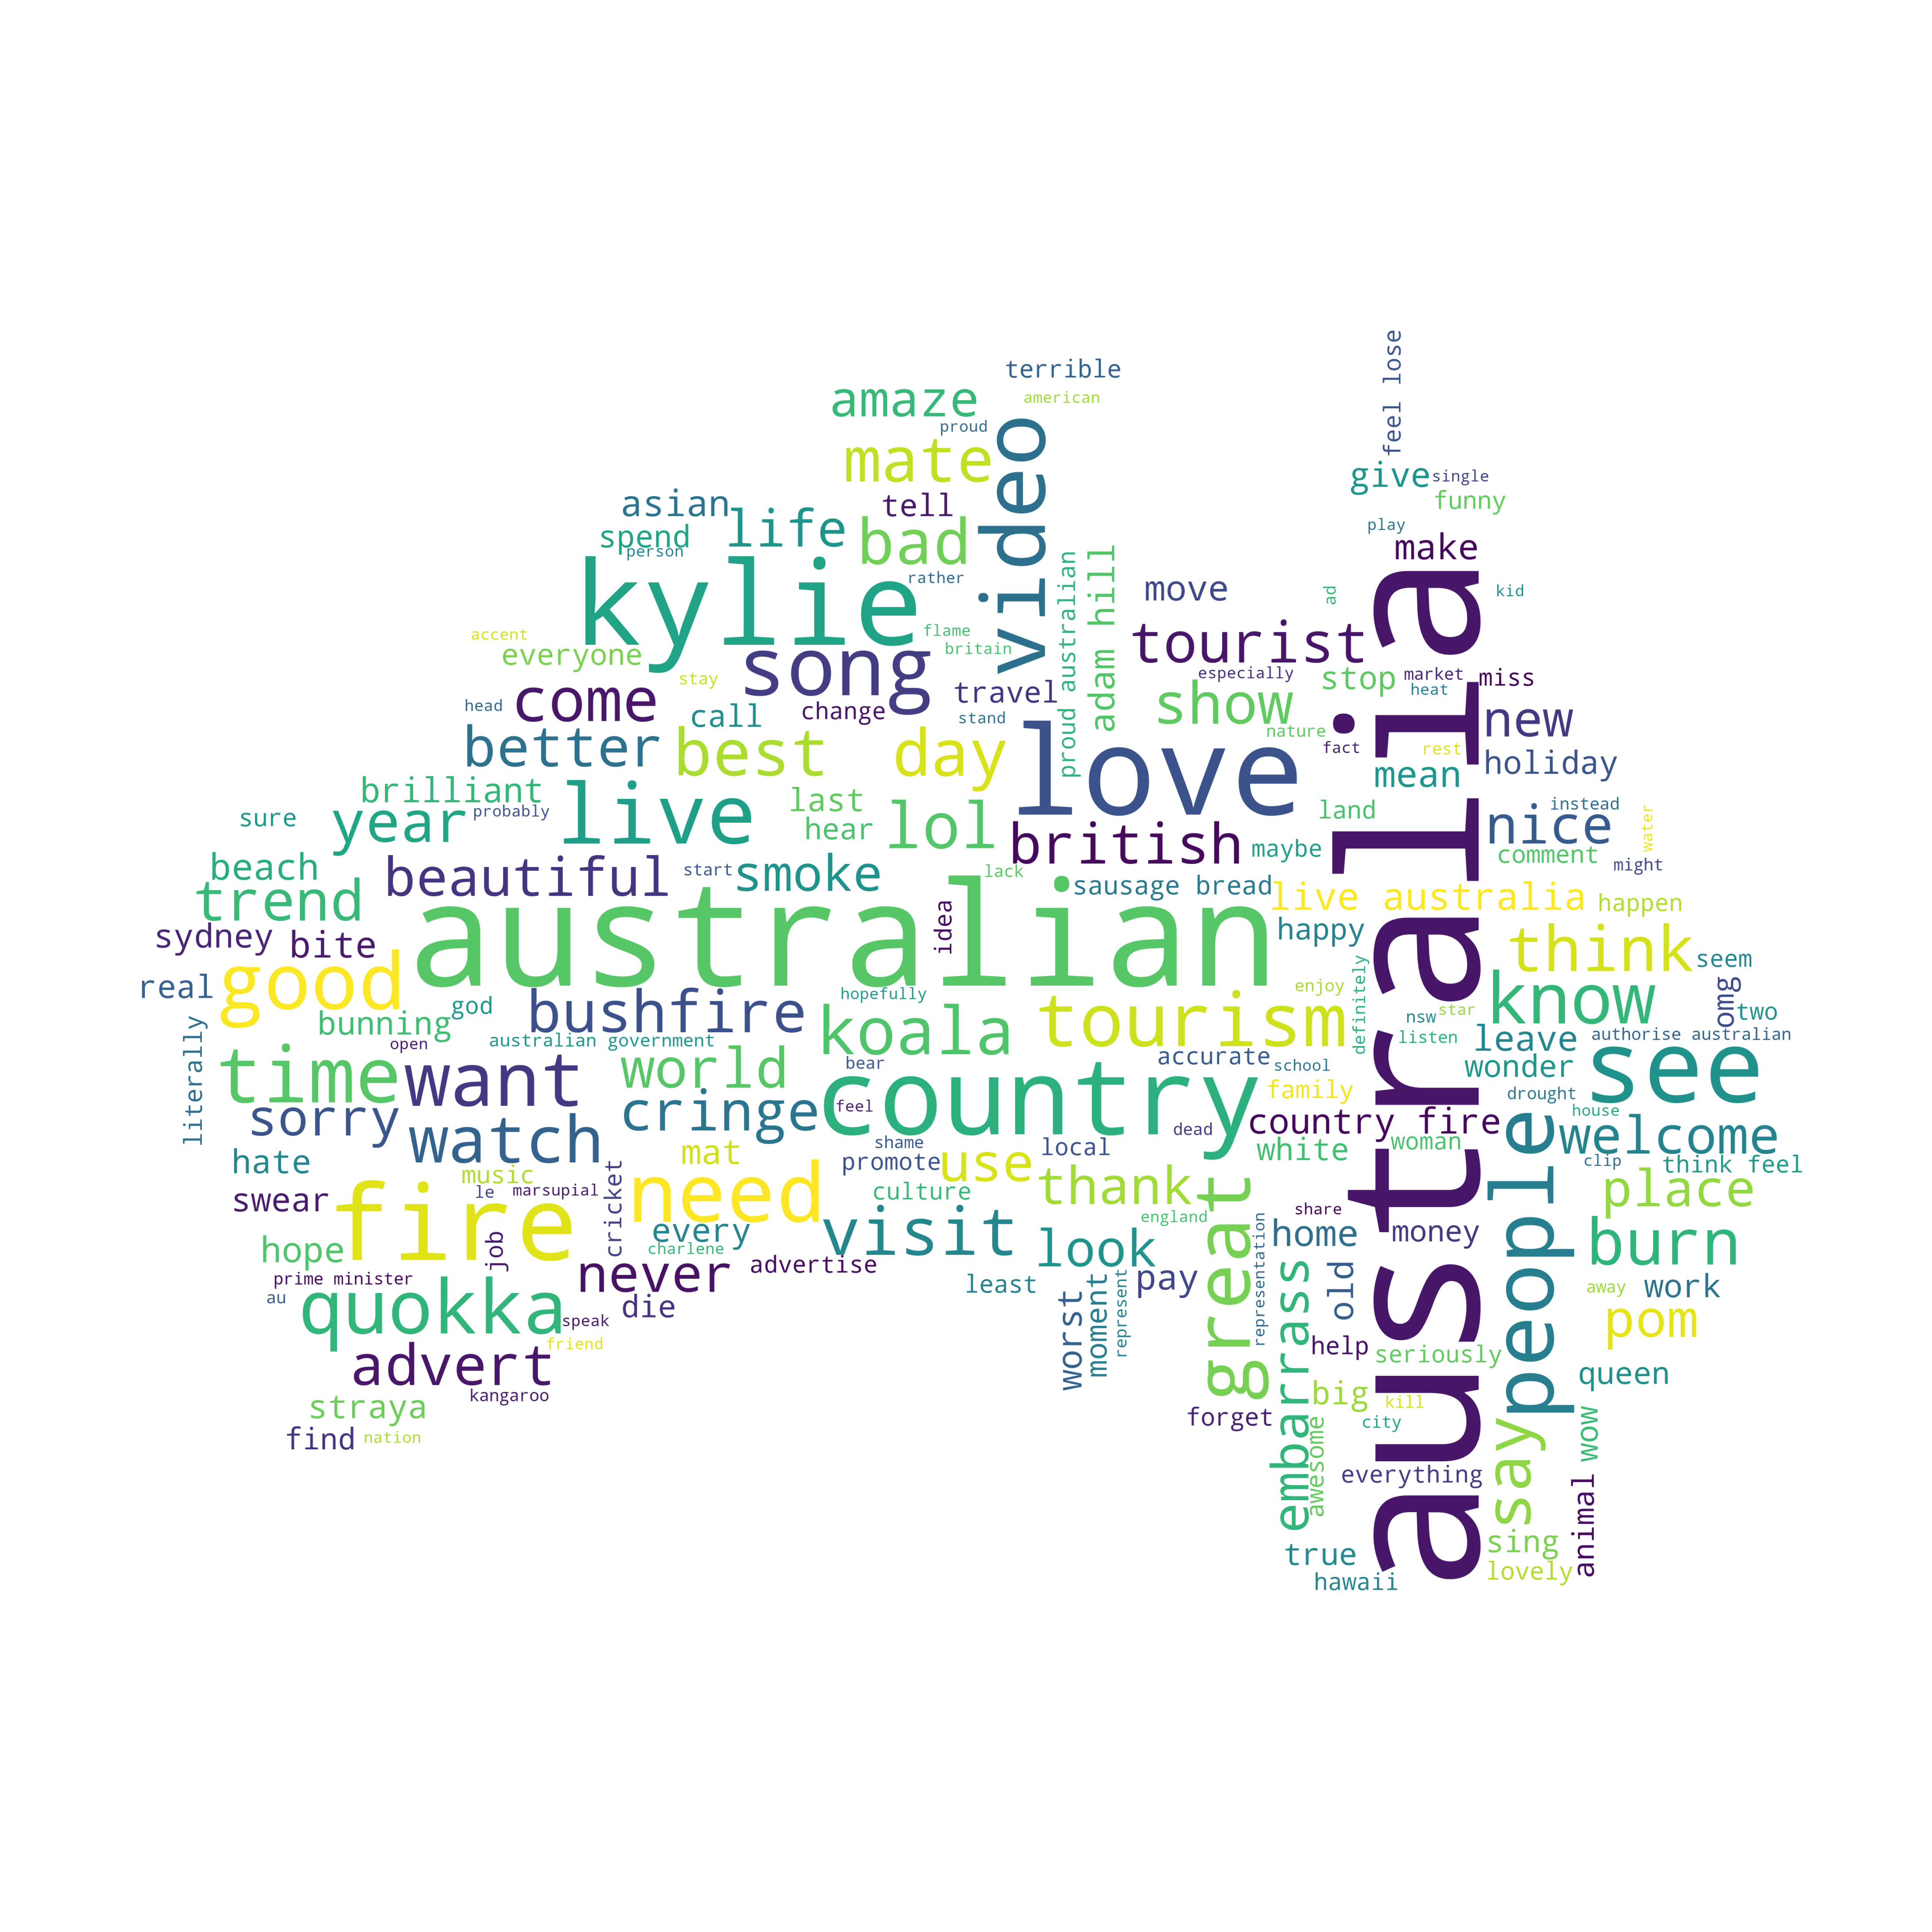

In [19]:
from wordcloud import WordCloud
mask = np.array(Image.open(r'C:\Users\jwan0\Aus_map.jpeg'))
all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(random_state=2, 
                     background_color='white', 
                     mask = mask,
                     width = mask.shape[1],
                     height = mask.shape[0],
                     max_font_size=500).generate(all_words_lem)


plt.figure(figsize=(100, 80))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

In [20]:
#Word frequency list

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

words = nltk.word_tokenize(all_words_lem)
fd = FreqDist(words)

In [21]:
fd.most_common(200)

[('australia', 348),
 ('australian', 199),
 ('love', 122),
 ('kylie', 116),
 ('like', 110),
 ('country', 102),
 ('fire', 98),
 ('see', 78),
 ('live', 70),
 ('video', 58),
 ('people', 56),
 ('think', 53),
 ('song', 50),
 ('need', 50),
 ('want', 49),
 ('good', 46),
 ('time', 45),
 ('great', 45),
 ('know', 44),
 ('tourism', 41),
 ('best', 37),
 ('quokka', 37),
 ('say', 33),
 ('visit', 32),
 ('koala', 32),
 ('day', 31),
 ('year', 31),
 ('come', 31),
 ('watch', 31),
 ('burn', 30),
 ('lol', 30),
 ('bad', 29),
 ('mate', 29),
 ('place', 25),
 ('feel', 25),
 ('show', 25),
 ('advert', 24),
 ('tourist', 24),
 ('trend', 24),
 ('british', 23),
 ('better', 23),
 ('world', 23),
 ('make', 23),
 ('new', 23),
 ('cringe', 23),
 ('adam', 22),
 ('look', 22),
 ('beautiful', 21),
 ('use', 21),
 ('nice', 21),
 ('welcome', 20),
 ('never', 20),
 ('thank', 20),
 ('pom', 20),
 ('life', 19),
 ('government', 19),
 ('sorry', 19),
 ('swear', 19),
 ('embarrass', 19),
 ('amaze', 18),
 ('smoke', 18),
 ('money', 18),
 ('

In [22]:
word_rank = fd.most_common(200)

WR = pd.DataFrame(word_rank)

WR.to_excel('Word_top_200_sw.xlsx')

In [23]:
top_20 = fd.most_common(20)

fdist = pd.Series(dict(top_20))

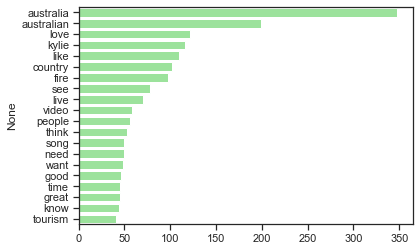

In [24]:
sns.set_theme(style="ticks")

sns.barplot(y=fdist.index, x=fdist.values, color='lightgreen');

In [25]:
from nltk.sentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['polarity'] = df['text_string_lem'].apply(lambda x: analyzer.polarity_scores(x))
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,polarity
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...,british living australia say friendly welcome ...,british live australia say friendly welcome op...,False,"{'neg': 0.0, 'neu': 0.556, 'pos': 0.444, 'comp..."
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...,british love australians australia definitely ...,british love australian australia definitely b...,False,"{'neg': 0.0, 'neu': 0.49, 'pos': 0.51, 'compou..."
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...,lyrics roll timeyou say say anybody cause stan...,lyric roll timeyou say say anybody cause stand...,False,"{'neg': 0.23, 'neu': 0.77, 'pos': 0.0, 'compou..."
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,True,"{'neg': 0.286, 'neu': 0.714, 'pos': 0.0, 'comp..."
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins,beautifully adore australian cousins,beautifully adore australian cousin,False,"{'neg': 0.0, 'neu': 0.215, 'pos': 0.785, 'comp..."


In [26]:
df = pd.concat(
    [df.drop(['polarity'], axis=1), df['polarity'].apply(pd.Series)], axis=1)
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...,british living australia say friendly welcome ...,british live australia say friendly welcome op...,False,0.000,0.556,0.444,0.9325
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...,british love australians australia definitely ...,british love australian australia definitely b...,False,0.000,0.490,0.510,0.9100
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...,lyrics roll timeyou say say anybody cause stan...,lyric roll timeyou say say anybody cause stand...,False,0.230,0.770,0.000,-0.9818
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,True,0.286,0.714,0.000,-0.3400
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins,beautifully adore australian cousins,beautifully adore australian cousin,False,0.000,0.215,0.785,0.8074


In [27]:
df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x >0 else 'neutral' if x==0 else 'negative')
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,Danny LaRue,"As a Brit living in Australia, I can say it re...","as a british living in australia, i can say it...","[british, living, australia, say, friendly, we...",british living australia say friendly welcome ...,british living australia say friendly welcome ...,british live australia say friendly welcome op...,False,0.000,0.556,0.444,0.9325,positive
1,Josh ando,Well I’m British and love australians and Aust...,well i’m british and love australians and aust...,"[british, love, australians, australia, defini...",british love australians australia definitely ...,british love australians australia definitely ...,british love australian australia definitely b...,False,0.000,0.490,0.510,0.9100,positive
2,Yeah,LyricsYou gotta roll with itYou gotta take you...,lyrics you gotta roll with it you gotta take y...,"[lyrics, gotta, roll, gotta, timeyou, gotta, s...",lyrics gotta roll gotta timeyou gotta say say ...,lyrics roll timeyou say say anybody cause stan...,lyric roll timeyou say say anybody cause stand...,False,0.230,0.770,0.000,-0.9818,negative
3,JohnsontheFly,"This is pretty well done, but the real tourism...","this is pretty well done, but the real tourism...","[real, tourism, theme, see, smo, aaaa, fire]",real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,real tourism theme see smo aaaa fire,True,0.286,0.714,0.000,-0.3400,negative
4,James B,"Beautifully done, I adore my my australian cou...","beautifully done, i adore my australian cousins.","[beautifully, adore, australian, cousins]",beautifully adore australian cousins,beautifully adore australian cousins,beautifully adore australian cousin,False,0.000,0.215,0.785,0.8074,positive


In [28]:
df.loc[df['compound'].idxmax()].values
print()
# Tweet with highest negative sentiment 
# ...seems to be a case of wrong classification because of the word "deficit"
df.loc[df['compound'].idxmin()].values

array(['  Yeah',
       "LyricsYou gotta roll with itYou gotta take your timeYou gotta say what you sayDon't let anybody get in your way'Cause it's all too much for me to takeDon't ever stand asideDon't ever be deniedYou wanna be who you'd beIf you're coming with meI think I've got a feeling I've lost insideI think I'm gonna take me away and hideI'm thinking of things that I just can't abideI know the roads down which your life will driveI find the key that lets you slip insideKiss the girl, she's not behind the doorBut you know I think I recognize your faceBut I've never seen you beforeYou gotta roll with itYou gotta take your timeYou gotta say what you sayDon't let any fucker get in your way'Cause it's all too much for me to takeI know the roads down which your life will driveI find the key that lets you slip insideKiss the girl, she's not behind the doorBut you know I think I recognize your faceBut I've never seen you beforeYou gotta roll with itYou gotta take your timeYou gotta say

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_35132/1332496738.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment',


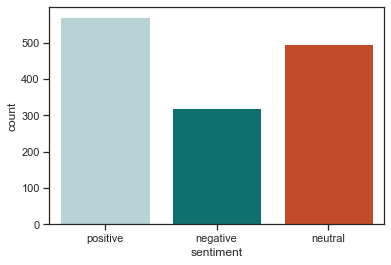

In [29]:
sns.countplot(x='sentiment', 
             data=df, 
             palette=['#b2d8d8',"#008080", '#db3d13']
             );

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_35132/2680373653.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='compound',


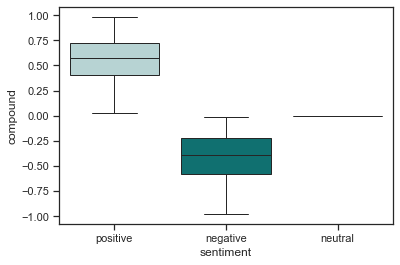

In [30]:
sns.boxplot(y='compound', 
            x='sentiment',
            palette=['#b2d8d8',"#008080", '#db3d13'], 
            data=df);

In [31]:
WR.to_excel('Word_top_200_sw.xlsx')

In [32]:
#social network
cleaned_text = df['text_string_lem']
cleaned_text.reset_index(inplace=True, drop=True) # 인덱스 초기화

In [33]:
tokenizer = RegexpTokenizer('[\w]+')

count = {} # 동시출현 빈도가 저장될 dict

for line in cleaned_text:
    words = line
    tokens = tokenizer.tokenize(words) # 각 리뷰를 토큰화한 뒤 리스트에 저장
    stopped_tokens = [i for i in list(set(tokens)) if not i in stopwords]
    stopped_tokens2 = [i for i in stopped_tokens if len(i)>1]
    for i,a in enumerate(stopped_tokens2):
        for b in stopped_tokens2[i+1:]:
            if a>b:
                count[b,a] = count.get((b,a),0) + 1
            else:
                count[a,b] = count.get((a,b),0) + 1
                
df1 = pd.DataFrame.from_dict(count, orient='index')

list1=[]
for i in range(len(df)):
    list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])

df2 = pd.DataFrame(list1, columns=['term1','term2','freq'])
df3 = df2.sort_values(by=['freq'], ascending=False) # freq 기준으로 내림차순 정렬
df3_nw = df3.reset_index(drop=True)

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_35132/868560440.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])


In [34]:
YT_au_nw = nx.Graph()

# 동시출현 빈도가 1n이상인 단어들에 대해서만 중심성 계수 계산
n =3
for i in range((len(np.where(df3_nw['freq']>n)[0]))):
    YT_au_nw.add_edge(df3_nw['term1'][i], df3_nw['term2'][i],
                  weight=int(df3_nw['freq'][i]))

dgr = nx.degree_centrality(YT_au_nw) # 연결 중심성
btw = nx.betweenness_centrality(YT_au_nw) # 매개 중심성
cls = nx.closeness_centrality(YT_au_nw) # 근접 중심성
egv = nx.eigenvector_centrality(YT_au_nw) # 고유벡터 중심성

sorted_dgr = sorted(dgr.items(), key=operator.itemgetter(1), reverse=True)
sorted_btw = sorted(btw.items(), key=operator.itemgetter(1), reverse=True)
sorted_cls = sorted(cls.items(), key=operator.itemgetter(1), reverse=True)
sorted_egv = sorted(egv.items(), key=operator.itemgetter(1), reverse=True)

print("** degree **")
for x in range(24):
    print(sorted_dgr[x])

print("** betweenness **")
for x in range(24):
    print(sorted_btw[x])
    
print("** closeness **")
for x in range(24):
    print(sorted_cls[x])

print("** eigenvector **")
for x in range(24):
    print(sorted_egv[x])

** degree **
('australia', 0.6296296296296295)
('know', 0.48148148148148145)
('country', 0.4444444444444444)
('australian', 0.37037037037037035)
('like', 0.3333333333333333)
('see', 0.3333333333333333)
('british', 0.25925925925925924)
('love', 0.2222222222222222)
('live', 0.2222222222222222)
('advert', 0.18518518518518517)
('think', 0.14814814814814814)
('song', 0.14814814814814814)
('never', 0.14814814814814814)
('say', 0.14814814814814814)
('visit', 0.1111111111111111)
('place', 0.1111111111111111)
('time', 0.1111111111111111)
('day', 0.1111111111111111)
('welcome', 0.1111111111111111)
('lose', 0.07407407407407407)
('life', 0.07407407407407407)
('fire', 0.037037037037037035)
('tourism', 0.037037037037037035)
('share', 0.037037037037037035)
** betweenness **
('know', 0.40870980870980883)
('australia', 0.3451499118165785)
('see', 0.2640550807217474)
('like', 0.08869895536562203)
('country', 0.08766788766788766)
('australian', 0.03553113553113554)
('song', 0.03211233211233211)
('time', 

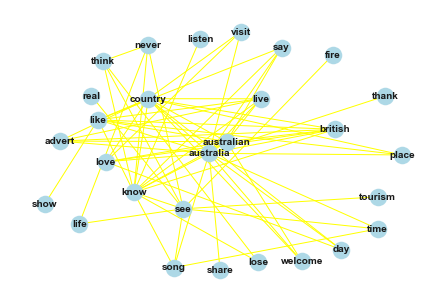

<Figure size 2e+06x2e+06 with 0 Axes>

In [35]:
nx.draw(YT_au_nw, pos = nx.spring_layout(YT_au_nw, k=4),
    node_color='lightblue', linewidths=0.125, font_size=10,
    font_weight='bold', edge_color= 'yellow', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

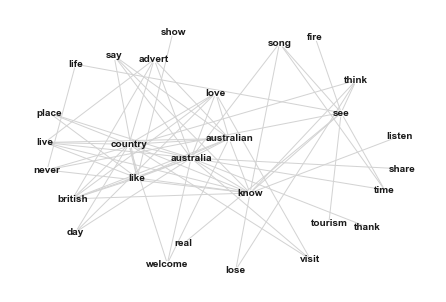

<Figure size 2e+06x2e+06 with 0 Axes>

In [36]:
nx.draw(YT_au_nw, pos = nx.spring_layout(YT_au_nw, k=4),
    node_color='white', linewidths=0, font_size=10, node_size = 50,
    font_weight='bold', edge_color= 'lightgrey', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

In [37]:
stop_words = stopwords

#LDA Topic modeling

vect =TfidfVectorizer(stop_words=stop_words,max_features=1000)
vect_text=vect.fit_transform(df['text_string_lem'])

In [38]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model=LatentDirichletAllocation(n_components=10,
learning_method='online',random_state=42,max_iter=1) 
lda_top=lda_model.fit_transform(vect_text)

In [39]:
print("Document : ")
for i,topic in enumerate(lda_top[0]):
  print("Topic ",i+1,": ",topic*100,"%")

Document : 
Topic  1 :  1.7665298620427459 %
Topic  2 :  1.766230886188609 %
Topic  3 :  1.7660883120973623 %
Topic  4 :  1.7660862206796506 %
Topic  5 :  1.7670493653772028 %
Topic  6 :  84.10223897510454 %
Topic  7 :  1.7661946983312231 %
Topic  8 :  1.7660850141640179 %
Topic  9 :  1.7674093566488729 %
Topic  10 :  1.7660873093657732 %


In [40]:
vocab = vect.get_feature_names()
for i, comp in enumerate(lda_model.components_):
     vocab_comp = zip(vocab, comp)
     sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:10]
     print("Topic "+str(i+1)+": ")
     for t in sorted_words:
            print(t[0],end=" ")
            print('\n')

Topic 1: 
kylie 

embarrass 

mate 

swear 

australia 

need 

love 

bunnings 

song 

quokka 

Topic 2: 
pay 

sound 

wonder 

waste 

sandringham 

woman 

like 

confuse 

smoke 

cost 

Topic 3: 
cringe 

shrimp 

jump 

afl 

scomo 

rhyme 

bogan 

barbie 

bogans 

shocker 

Topic 4: 
love 

new 

authorise 

cheer 

vomit 

government 

australian 

canberra 

beard 

national 

Topic 5: 
australia 

thank 

australian 

world 

god 

country 

koala 

place 

lmao 

accurate 

Topic 6: 
australia 

fire 

live 

trend 

country 

want 

kylie 

great 

terrible 

australian 

Topic 7: 
australian 

good 

like 

sausage 

old 

australia 

youtube 

fake 

kylie 

nice 

Topic 8: 
lol 

worst 

best 

pom 

omg 

love 

tourism 

minogue 

two 

overreact 

Topic 9: 
see 

bad 

time 

bushfires 

adam 

australia 

hill 

hope 

fire 

bite 

Topic 10: 
video 

watch 

sorry 

asian 

sydney 

stop 

australia 

cool 

funny 

like 



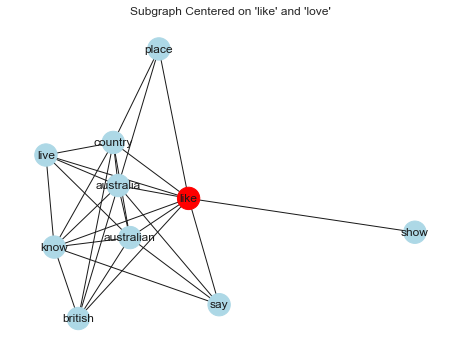

In [41]:
# Define your center keywords
center_keywords = 'like'

# Ensure these nodes exist in the full network
center_nodes = [node for node in YT_au_nw.nodes() if node in center_keywords]

# Collect all neighbors (1-hop) of the center keywords
neighbors = set()
for node in center_nodes:
    neighbors.update(nx.all_neighbors(YT_au_nw, node))
# Also include the center nodes themselves
neighbors.update(center_nodes)

# Create the subgraph
subgraph = YT_au_nw.subgraph(neighbors)

# (Optional) Compute centrality measures for additional insight
degree_cent = nx.degree_centrality(subgraph)
betweenness_cent = nx.betweenness_centrality(subgraph)
closeness_cent = nx.closeness_centrality(subgraph)
eigenvector_cent = nx.eigenvector_centrality(subgraph)


# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=42)
node_colors = ['red' if node in center_keywords else 'lightblue' for node in subgraph.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subgraph, pos)
nx.draw_networkx_labels(subgraph, pos)
plt.title("Subgraph Centered on 'like' and 'love'")
plt.axis('off')
plt.show()

In [42]:
# Create a DataFrame to combine these centrality measures
centralities_table = pd.DataFrame({
    'Node': list(subgraph.nodes()),
    'Degree': [degree_cent[node] for node in subgraph.nodes()],
    'Betweenness': [betweenness_cent[node] for node in subgraph.nodes()],
    'Closeness': [closeness_cent[node] for node in subgraph.nodes()],
    'Eigenvector': [eigenvector_cent[node] for node in subgraph.nodes()]
})

# Sort the table by Degree centrality (or any other measure) for easier interpretation
centralities_table = centralities_table.sort_values(by='Degree', ascending=False)

# Display the table
print(centralities_table)

         Node    Degree  Betweenness  Closeness  Eigenvector
0        like  1.000000     0.299537   1.000000     0.404203
3   australia  0.888889     0.077315   0.900000     0.395646
2  australian  0.777778     0.026389   0.818182     0.371028
6     country  0.777778     0.042593   0.818182     0.363003
8        know  0.777778     0.026389   0.818182     0.371028
5        live  0.555556     0.000000   0.692308     0.298059
7     british  0.555556     0.000000   0.692308     0.298059
4         say  0.444444     0.000000   0.642857     0.241260
1       place  0.333333     0.000000   0.600000     0.181950
9        show  0.111111     0.000000   0.529412     0.063245


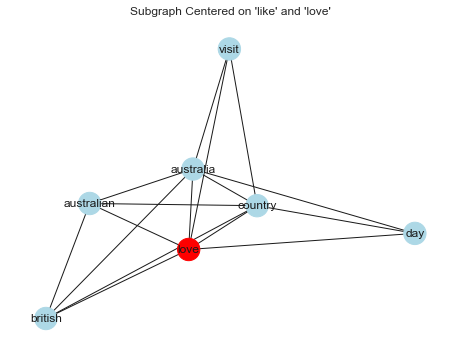

In [43]:
# Define your center keywords
center_keywords = 'love'

# Ensure these nodes exist in the full network
center_nodes = [node for node in YT_au_nw.nodes() if node in center_keywords]

# Collect all neighbors (1-hop) of the center keywords
neighbors = set()
for node in center_nodes:
    neighbors.update(nx.all_neighbors(YT_au_nw, node))
# Also include the center nodes themselves
neighbors.update(center_nodes)

# Create the subgraph
subgraph = YT_au_nw.subgraph(neighbors)

# (Optional) Compute centrality measures for additional insight
degree_cent = nx.degree_centrality(subgraph)
betweenness_cent = nx.betweenness_centrality(subgraph)
closeness_cent = nx.closeness_centrality(subgraph)
eigenvector_cent = nx.eigenvector_centrality(subgraph)


# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=42)
node_colors = ['red' if node in center_keywords else 'lightblue' for node in subgraph.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subgraph, pos)
nx.draw_networkx_labels(subgraph, pos)
plt.title("Subgraph Centered on 'like' and 'love'")
plt.axis('off')
plt.show()

In [44]:
# Create a DataFrame to combine these centrality measures
centralities_table = pd.DataFrame({
    'Node': list(subgraph.nodes()),
    'Degree': [degree_cent[node] for node in subgraph.nodes()],
    'Betweenness': [betweenness_cent[node] for node in subgraph.nodes()],
    'Closeness': [closeness_cent[node] for node in subgraph.nodes()],
    'Eigenvector': [eigenvector_cent[node] for node in subgraph.nodes()]
})

# Sort the table by Degree centrality (or any other measure) for easier interpretation
centralities_table = centralities_table.sort_values(by='Degree', ascending=False)

# Display the table
print(centralities_table)

         Node    Degree  Betweenness  Closeness  Eigenvector
1        love  1.000000     0.111111   1.000000     0.446727
4   australia  1.000000     0.111111   1.000000     0.446727
6     country  1.000000     0.111111   1.000000     0.446727
2  australian  0.666667     0.000000   0.750000     0.351080
5     british  0.666667     0.000000   0.750000     0.351080
0         day  0.500000     0.000000   0.666667     0.278201
3       visit  0.500000     0.000000   0.666667     0.278201


Topic 1: ['kylie', 'embarrass', 'mate', 'swear', 'australia', 'need', 'love', 'bunnings', 'song', 'quokka']
Topic 2: ['pay', 'sound', 'wonder', 'waste', 'sandringham', 'woman', 'like', 'confuse', 'smoke', 'cost']
Topic 3: ['cringe', 'shrimp', 'jump', 'afl', 'scomo', 'rhyme', 'bogan', 'barbie', 'bogans', 'shocker']
Topic 4: ['love', 'new', 'authorise', 'cheer', 'vomit', 'government', 'australian', 'canberra', 'beard', 'national']
Topic 5: ['australia', 'thank', 'australian', 'world', 'god', 'country', 'koala', 'place', 'lmao', 'accurate']
Topic 6: ['australia', 'fire', 'live', 'trend', 'country', 'want', 'kylie', 'great', 'terrible', 'australian']
Topic 7: ['australian', 'good', 'like', 'sausage', 'old', 'australia', 'youtube', 'fake', 'kylie', 'nice']
Topic 8: ['lol', 'worst', 'best', 'pom', 'omg', 'love', 'tourism', 'minogue', 'two', 'overreact']
Topic 9: ['see', 'bad', 'time', 'bushfires', 'adam', 'australia', 'hill', 'hope', 'fire', 'bite']
Topic 10: ['video', 'watch', 'sorry', 'asi

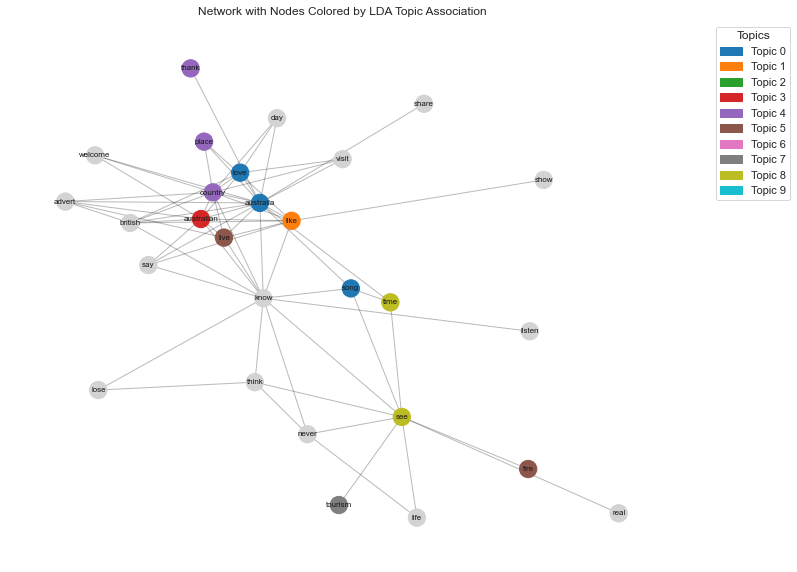

In [45]:
import matplotlib.patches as mpatches

# Number of top words to extract per topic
num_top_words = 10
vocab = vect.get_feature_names()  # from your TfidfVectorizer
topic_top_words = {}

# Extract top words for each topic
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-num_top_words:][::-1]
    topic_top_words[topic_idx] = [vocab[i] for i in top_indices]
    print(f"Topic {topic_idx+1}: {topic_top_words[topic_idx]}")

# Create a mapping: word -> list of topics where it appears in the top words
node_topic_mapping = {}
for topic_idx, words in topic_top_words.items():
    for word in words:
        if word in YT_au_nw.nodes():
            node_topic_mapping.setdefault(word, []).append(topic_idx)

# For visualization, assign a color based on the first associated topic.
# (You can expand this if a node is linked to multiple topics.)
color_map = []
for node in YT_au_nw.nodes():
    if node in node_topic_mapping:
        # Use the topic index to select a color from a colormap (e.g., tab10)
        topic_idx = node_topic_mapping[node][0]
        color = plt.cm.tab10(topic_idx)
    else:
        color = 'lightgrey'
    color_map.append(color)

# Visualize the full network with nodes colored by their LDA topic association
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(YT_au_nw, seed=42)
nx.draw_networkx_nodes(YT_au_nw, pos, node_color=color_map, node_size=300)
nx.draw_networkx_edges(YT_au_nw, pos, alpha=0.3)
nx.draw_networkx_labels(YT_au_nw, pos, font_size=8)
plt.title("Network with Nodes Colored by LDA Topic Association")
plt.axis('off')

# Create legend handles for each topic using the tab10 colormap
num_topics = lda_model.components_.shape[0]
legend_handles = [
    mpatches.Patch(color=plt.cm.tab10(topic_idx), label=f"Topic {topic_idx}")
    for topic_idx in range(num_topics)
]

# Add the legend to the plot
plt.legend(handles=legend_handles, title="Topics", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [46]:
# Construct a DataFrame with topics and their top words
df_topics = pd.DataFrame({
    'Topic': [f"Topic {i+1}" for i in range(len(topic_top_words))],
    'Top Words': [', '.join(topic_top_words[i]) for i in range(len(topic_top_words))]
})

df_topics.head(10)

,Topic,Top Words
0,Topic 1,"kylie, embarrass, mate, swear, australia, need..."
1,Topic 2,"pay, sound, wonder, waste, sandringham, woman,..."
2,Topic 3,"cringe, shrimp, jump, afl, scomo, rhyme, bogan..."
3,Topic 4,"love, new, authorise, cheer, vomit, government..."
4,Topic 5,"australia, thank, australian, world, god, coun..."
5,Topic 6,"australia, fire, live, trend, country, want, k..."
6,Topic 7,"australian, good, like, sausage, old, australi..."
7,Topic 8,"lol, worst, best, pom, omg, love, tourism, min..."
8,Topic 9,"see, bad, time, bushfires, adam, australia, hi..."
9,Topic 10,"video, watch, sorry, asian, sydney, stop, aust..."
